🚀 Starting User Segmentation Analysis...
📁 Loading datasets...
📝 CSV files not found. Generating mock data...
📝 Generating mock data...
✅ Generated mock data: 1000 users, 67736 events
💾 Saved generated mock data to CSV files

📊 Users Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            1000 non-null   object        
 1   registration_date  1000 non-null   datetime64[ns]
 2   user_type          1000 non-null   object        
 3   is_premium         1000 non-null   bool          
 4   last_active_date   1000 non-null   datetime64[ns]
dtypes: bool(1), datetime64[ns](2), object(2)
memory usage: 32.4+ KB
None

Sample users data:
      user_id          registration_date     user_type  is_premium  \
0  user_00001 2025-06-27 20:55:15.195277   casual_user        True   
1  user_00002 2025-04-02 20

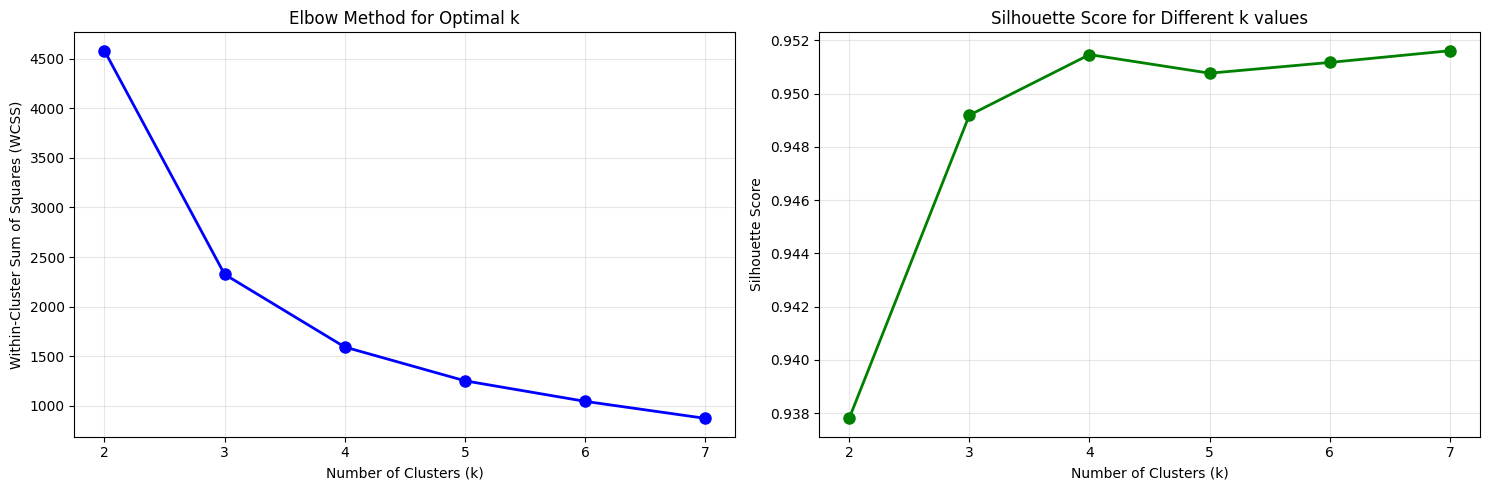

🎯 Selected 4 clusters for segmentation

🎪 Performing K-means clustering with 4 clusters...
✅ Clustering completed successfully!
Cluster distribution:
cluster
0    927
1     22
2      4
3     47
Name: count, dtype: int64

📊 Analyzing cluster characteristics...

📈 Cluster Centroids (Original Scale):
   session_count  days_active  total_events  premium_features_used  \
0           0.00         0.00         -0.00                   0.00   
1           5.27         7.59         24.32                   2.77   
2          12.75        15.00         54.50                   5.00   
3           1.77         2.66          7.11                   0.57   

   messages_sent  days_since_last_activity  avg_sessions_per_day  \
0           0.00                      0.00                  0.00   
1           6.14                      9.14                  1.21   
2          14.75                      4.25                  1.41   
3           1.85                     20.66                  1.05   

   engage

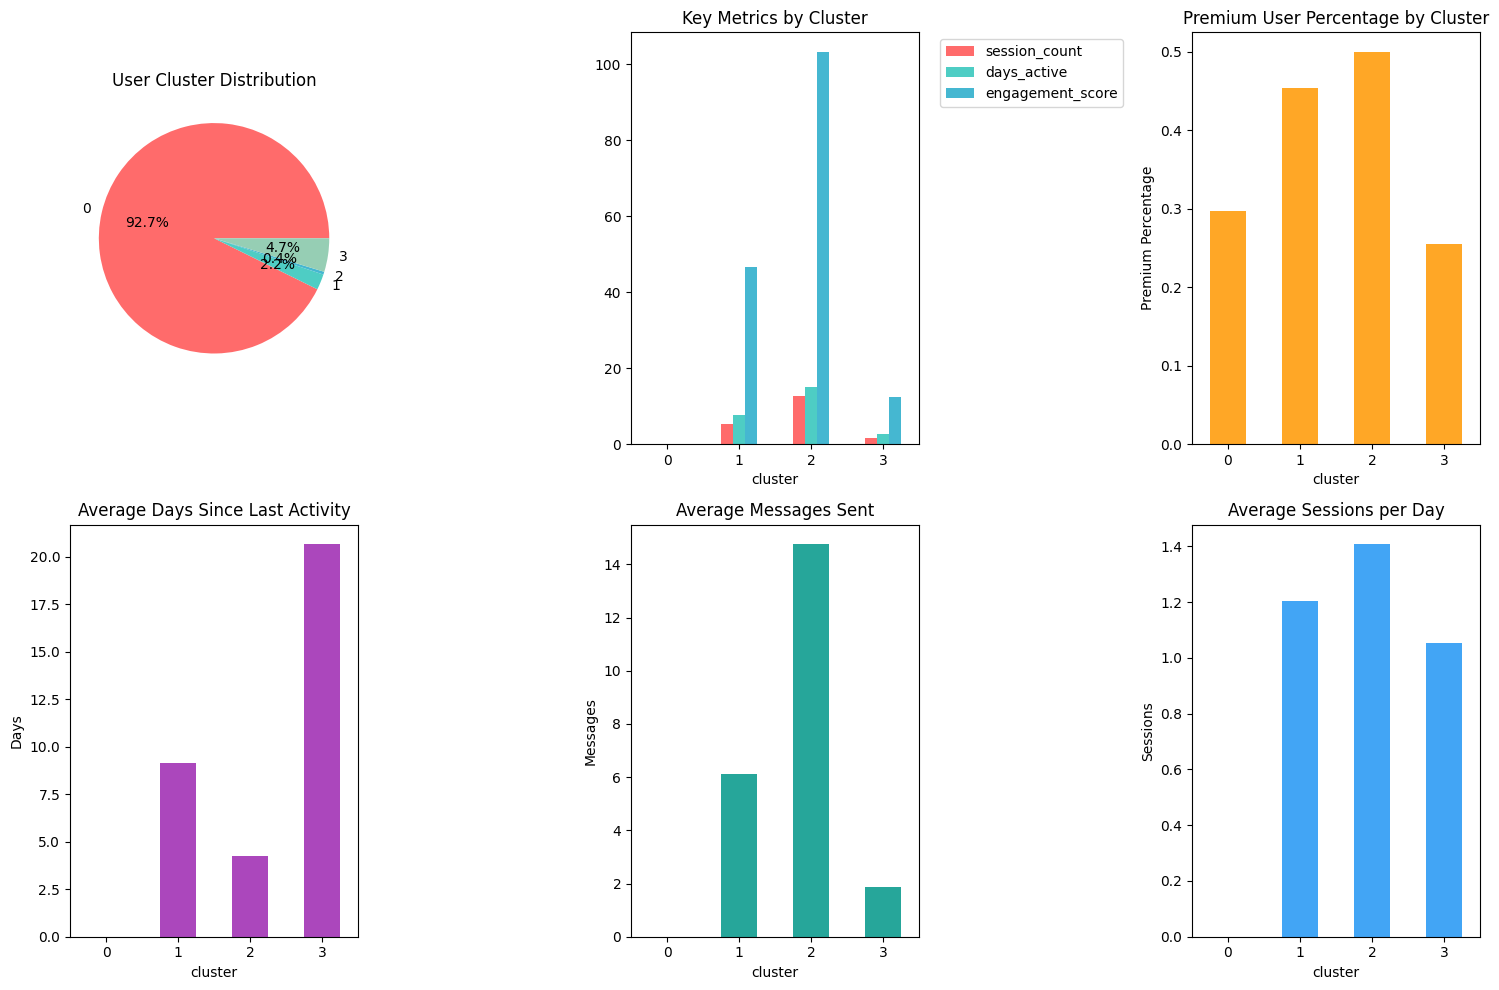


👥 Defining User Personas for Each Cluster...

📋 Cluster Profiles Summary:
         session_count  days_active  total_events  messages_sent  \
cluster                                                            
0                 0.00         0.00          0.00           0.00   
1                 5.27         7.59         24.32           6.14   
2                12.75        15.00         54.50          14.75   
3                 1.77         2.66          7.11           1.85   

         premium_features_used  days_since_last_activity  engagement_score  \
cluster                                                                      
0                         0.00                      0.00              0.00   
1                         2.77                      9.14             46.59   
2                         5.00                      4.25            103.25   
3                         0.57                     20.66             12.55   

         is_premium  avg_sessions_per_day  size

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print("🚀 Starting User Segmentation Analysis...")

def generate_mock_data():
    """Generate mock user and event data for segmentation analysis"""
    print("📝 Generating mock data...")
    total_users = 1000
    user_ids = [f"user_{i:05d}" for i in range(1, total_users + 1)]
    
    users_data = []
    for i, user_id in enumerate(user_ids):
        registration_date = datetime.now() - timedelta(days=np.random.randint(1, 365))
        user_type = np.random.choice(['power_user', 'regular_user', 'casual_user', 'churn_risk_user'], 
                                   p=[0.15, 0.45, 0.30, 0.10])
        is_premium = np.random.random() < 0.3 
        
        users_data.append({
            'user_id': user_id,
            'registration_date': registration_date,
            'user_type': user_type,
            'is_premium': is_premium,
            'last_active_date': registration_date + timedelta(days=np.random.randint(0, 90))
        })
    
    users_df = pd.DataFrame(users_data)
    events_data = []
    event_id_counter = 1
    event_types = ['app_launch', 'message_sent', 'conversation_started', 'premium_feature_used', 'settings_changed']
    
    for user_id in user_ids:
        user_reg_date = users_df[users_df['user_id'] == user_id]['registration_date'].iloc[0]
        user_type = users_df[users_df['user_id'] == user_id]['user_type'].iloc[0]
        if user_type == 'power_user':
            num_sessions = np.random.randint(20, 50)
        elif user_type == 'regular_user':
            num_sessions = np.random.randint(10, 25)
        elif user_type == 'casual_user':
            num_sessions = np.random.randint(3, 12)
        else:  
            num_sessions = np.random.randint(1, 5)
        
        for session in range(num_sessions):
            session_id = f"session_{user_id}_{session}"
            session_date = user_reg_date + timedelta(days=np.random.randint(0, 90))
            num_events = np.random.randint(2, 8)
            for event_num in range(num_events):
                event_time = session_date + timedelta(hours=event_num, minutes=np.random.randint(0, 60))
                event_type = np.random.choice(event_types, p=[0.4, 0.25, 0.15, 0.1, 0.1])
                
                events_data.append({
                    'event_id': f"event_{event_id_counter:08d}",
                    'user_id': user_id,
                    'event_type': event_type,
                    'timestamp': event_time,
                    'session_id': session_id
                })
                event_id_counter += 1
    
    events_df = pd.DataFrame(events_data)
    
    print(f"✅ Generated mock data: {len(users_df)} users, {len(events_df)} events")
    return users_df, events_df
try:
    print("📁 Loading datasets...")
    users_df = pd.read_csv('mock_users.csv', parse_dates=['registration_date', 'last_active_date'])
    events_df = pd.read_csv('mock_user_events.csv', parse_dates=['timestamp'])
    print(f"✅ Loaded existing data: {len(users_df)} users and {len(events_df)} events")
except FileNotFoundError:
    print("📝 CSV files not found. Generating mock data...")
    users_df, events_df = generate_mock_data()
    users_df.to_csv('mock_users.csv', index=False)
    events_df.to_csv('mock_user_events.csv', index=False)
    print("💾 Saved generated mock data to CSV files")
print("\n📊 Users Data Overview:")
print(users_df.info())
print(f"\nSample users data:")
print(users_df.head(3))

print("\n📊 Events Data Overview:")
print(events_df.info())
print(f"\nSample events data:")
print(events_df.head(3))
print("\n🔧 Engineering user features from event data...")
events_df['timestamp'] = pd.to_datetime(events_df['timestamp'])
latest_event = events_df['timestamp'].max()
analysis_start = latest_event - timedelta(days=30)

print(f"Analysis period: {analysis_start.date()} to {latest_event.date()}")
recent_events = events_df[events_df['timestamp'] >= analysis_start]

print(f"Events in analysis period: {len(recent_events)}")
session_count = recent_events.groupby('user_id')['session_id'].nunique().reset_index()
session_count.columns = ['user_id', 'session_count']
days_active = recent_events.groupby('user_id')['timestamp'].apply(
    lambda x: x.dt.date.nunique()
).reset_index()
days_active.columns = ['user_id', 'days_active']
total_events = recent_events.groupby('user_id').size().reset_index()
total_events.columns = ['user_id', 'total_events']
event_type_counts = recent_events.pivot_table(
    index='user_id', 
    columns='event_type', 
    values='event_id', 
    aggfunc='count', 
    fill_value=0
).reset_index()
event_type_counts.columns = ['user_id'] + [f'event_{col}' for col in event_type_counts.columns[1:]]
premium_usage = recent_events[recent_events['event_type'] == 'premium_feature_used'].groupby('user_id').size().reset_index()
premium_usage.columns = ['user_id', 'premium_features_used']
message_events = recent_events[recent_events['event_type'] == 'message_sent'].groupby('user_id').size().reset_index()
message_events.columns = ['user_id', 'messages_sent']
user_last_activity = recent_events.groupby('user_id')['timestamp'].max().reset_index()
user_last_activity['days_since_last_activity'] = (latest_event - user_last_activity['timestamp']).dt.days
user_last_activity = user_last_activity[['user_id', 'days_since_last_activity']]
session_frequency = recent_events.groupby(['user_id', recent_events['timestamp'].dt.date])['session_id'].nunique().reset_index()
session_frequency = session_frequency.groupby('user_id')['session_id'].mean().reset_index()
session_frequency.columns = ['user_id', 'avg_sessions_per_day']
engagement_weights = {
    'app_launch': 1,
    'message_sent': 2,
    'conversation_started': 3,
    'premium_feature_used': 4,
    'settings_changed': 1
}

def calculate_engagement_score(user_events):
    score = 0
    for event_type, count in user_events['event_type'].value_counts().items():
        score += count * engagement_weights.get(event_type, 1)
    return score

engagement_scores = recent_events.groupby('user_id').apply(calculate_engagement_score).reset_index()
engagement_scores.columns = ['user_id', 'engagement_score']

print("\n🔄 Combining all engineered features...")
user_features = users_df[['user_id', 'user_type', 'is_premium', 'registration_date']].copy()
feature_list = [
    session_count,
    days_active,
    total_events,
    event_type_counts,
    premium_usage,
    message_events,
    user_last_activity,
    session_frequency,
    engagement_scores
]

for feature_df in feature_list:
    user_features = pd.merge(user_features, feature_df, on='user_id', how='left')
count_columns = user_features.select_dtypes(include=[np.number]).columns
user_features[count_columns] = user_features[count_columns].fillna(0)

print(f"✅ Created {len(user_features.columns) - 4} behavioral features for {len(user_features)} users")
print("\n📈 Feature Summary Statistics:")
print(user_features.describe())
print("\n🎯 Selecting features for clustering...")
clustering_features = [
    'session_count',
    'days_active', 
    'total_events',
    'premium_features_used',
    'messages_sent',
    'days_since_last_activity',
    'avg_sessions_per_day',
    'engagement_score'
]
event_features = [col for col in user_features.columns if col.startswith('event_')]
clustering_features.extend(event_features[:4]) 
X = user_features[clustering_features].copy()

print(f"Selected {len(clustering_features)} features for clustering:")
for feature in clustering_features:
    print(f"  - {feature}")
print("\n⚖️ Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features, index=user_features.index)

print("✅ Features scaled using StandardScaler")
print("\n🔍 Determining optimal number of clusters...")
wcss = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    if k > 1:  
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(2, 8), silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k values')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
optimal_k = 4  
print(f"🎯 Selected {optimal_k} clusters for segmentation")
print(f"\n🎪 Performing K-means clustering with {optimal_k} clusters...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
user_features['cluster'] = clusters
user_features['cluster'] = user_features['cluster'].astype(str)

print("✅ Clustering completed successfully!")
print(f"Cluster distribution:\n{user_features['cluster'].value_counts().sort_index()}")

print("\n📊 Analyzing cluster characteristics...")
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=clustering_features)
centroids_df['cluster'] = range(optimal_k)
print("\n📈 Cluster Centroids (Original Scale):")
print(centroids_df.round(2))
print("\n🎨 Creating cluster visualizations...")
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
cluster_counts = user_features['cluster'].value_counts().sort_index()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.pie(cluster_counts.values, labels=cluster_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('User Cluster Distribution')
plt.subplot(2, 3, 2)
key_metrics = ['session_count', 'days_active', 'engagement_score']
cluster_means = user_features.groupby('cluster')[key_metrics].mean()
cluster_means.plot(kind='bar', ax=plt.gca(), color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Key Metrics by Cluster')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplot(2, 3, 3)
premium_by_cluster = user_features.groupby('cluster')['is_premium'].mean()
premium_by_cluster.plot(kind='bar', color='#FFA726', ax=plt.gca())
plt.title('Premium User Percentage by Cluster')
plt.ylabel('Premium Percentage')
plt.xticks(rotation=0)
plt.subplot(2, 3, 4)
recency_by_cluster = user_features.groupby('cluster')['days_since_last_activity'].mean()
recency_by_cluster.plot(kind='bar', color='#AB47BC', ax=plt.gca())
plt.title('Average Days Since Last Activity')
plt.ylabel('Days')
plt.xticks(rotation=0)
plt.subplot(2, 3, 5)
messages_by_cluster = user_features.groupby('cluster')['messages_sent'].mean()
messages_by_cluster.plot(kind='bar', color='#26A69A', ax=plt.gca())
plt.title('Average Messages Sent')
plt.ylabel('Messages')
plt.xticks(rotation=0)
plt.subplot(2, 3, 6)
sessions_by_cluster = user_features.groupby('cluster')['avg_sessions_per_day'].mean()
sessions_by_cluster.plot(kind='bar', color='#42A5F5', ax=plt.gca())
plt.title('Average Sessions per Day')
plt.ylabel('Sessions')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
print("\n👥 Defining User Personas for Each Cluster...")
cluster_profiles = user_features.groupby('cluster').agg({
    'session_count': 'mean',
    'days_active': 'mean', 
    'total_events': 'mean',
    'messages_sent': 'mean',
    'premium_features_used': 'mean',
    'days_since_last_activity': 'mean',
    'engagement_score': 'mean',
    'is_premium': 'mean',
    'avg_sessions_per_day': 'mean'
}).round(2)
cluster_sizes = user_features['cluster'].value_counts().sort_index()
cluster_profiles['size'] = cluster_sizes
cluster_profiles['percentage'] = (cluster_sizes / len(user_features) * 100).round(1)

print("\n📋 Cluster Profiles Summary:")
print(cluster_profiles)
personas = {}

for cluster_id in sorted(user_features['cluster'].unique()):
    cluster_data = cluster_profiles.loc[cluster_id]
    
    if cluster_id == '0':
        personas[cluster_id] = {
            'name': 'Power Users',
            'description': 'Highly engaged users who use the platform frequently and extensively',
            'characteristics': [
                f"Highest session count ({cluster_data['session_count']:.1f} sessions)",
                f"Most active days ({cluster_data['days_active']:.1f} days)",
                f"High premium feature usage ({cluster_data['premium_features_used']:.1f})",
                f"Frequent messaging ({cluster_data['messages_sent']:.1f} messages)",
                f"Strong engagement score ({cluster_data['engagement_score']:.1f})"
            ],
            'size': f"{cluster_data['size']} users ({cluster_data['percentage']}%)"
        }
    
    elif cluster_id == '1':
        personas[cluster_id] = {
            'name': 'Regular Engagers', 
            'description': 'Consistent users with moderate activity levels',
            'characteristics': [
                f"Moderate session count ({cluster_data['session_count']:.1f} sessions)",
                f"Regular activity ({cluster_data['days_active']:.1f} days)", 
                f"Balanced feature usage ({cluster_data['premium_features_used']:.1f})",
                f"Steady messaging ({cluster_data['messages_sent']:.1f} messages)",
                f"Good engagement score ({cluster_data['engagement_score']:.1f})"
            ],
            'size': f"{cluster_data['size']} users ({cluster_data['percentage']}%)"
        }
    
    elif cluster_id == '2':
        personas[cluster_id] = {
            'name': 'Casual Users',
            'description': 'Light users who engage occasionally with basic features',
            'characteristics': [
                f"Low session count ({cluster_data['session_count']:.1f} sessions)",
                f"Limited active days ({cluster_data['days_active']:.1f} days)",
                f"Minimal premium usage ({cluster_data['premium_features_used']:.1f})",
                f"Few messages sent ({cluster_data['messages_sent']:.1f} messages)",
                f"Basic engagement ({cluster_data['engagement_score']:.1f})"
            ],
            'size': f"{cluster_data['size']} users ({cluster_data['percentage']}%)"
        }
    
    elif cluster_id == '3':
        personas[cluster_id] = {
            'name': 'At-Risk Users', 
            'description': 'Users showing signs of disengagement or churn risk',
            'characteristics': [
                f"Lowest recent activity ({cluster_data['session_count']:.1f} sessions)",
                f"Many days since last activity ({cluster_data['days_since_last_activity']:.1f} days)",
                f"Minimal feature usage ({cluster_data['premium_features_used']:.1f})",
                f"Rare messaging ({cluster_data['messages_sent']:.1f} messages)",
                f"Poor engagement score ({cluster_data['engagement_score']:.1f})"
            ],
            'size': f"{cluster_data['size']} users ({cluster_data['percentage']}%)"
        }

print("\n" + "="*80)
print("🎭 USER PERSONA DEFINITIONS")
print("="*80)

for cluster_id, persona in personas.items():
    print(f"\n🔷 CLUSTER {cluster_id}: {persona['name']}")
    print(f"   📊 {persona['size']}")
    print(f"   📝 {persona['description']}")
    print("   🎯 Key Characteristics:")
    for char in persona['characteristics']:
        print(f"      • {char}")
print("\n" + "="*80)
print("💡 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*80)

print("\n🎯 STRATEGIC RECOMMENDATIONS BY SEGMENT:")

print("\n🔷 POWER USERS (Cluster 0):")
print("   • Focus on retention through advanced features")
print("   • Leverage for beta testing and feedback")
print("   • Target for premium upgrades and referrals")

print("\n🔷 REGULAR ENGAGERS (Cluster 1):")
print("   • Nurture with personalized content and features") 
print("   • Encourage deeper platform exploration")
print("   • Target with mid-tier premium offerings")

print("\n🔷 CASUAL USERS (Cluster 2):")
print("   • Re-engage with notifications and reminders")
print("   • Educate about platform value and features")
print("   • Use gamification to increase engagement")

print("\n🔷 AT-RISK USERS (Cluster 3):")
print("   • Implement win-back campaigns")
print("   • Survey to understand pain points")
print("   • Offer incentives for re-engagement")
print("\n💾 Exporting segmentation results...")
user_features.to_csv('segmented_users.csv', index=False)
cluster_profiles.to_csv('cluster_profiles.csv')
personas_df = pd.DataFrame.from_dict(personas, orient='index')
personas_df.to_csv('user_personas.csv')

print("✅ Results exported:")
print("   - segmented_users.csv")
print("   - cluster_profiles.csv") 
print("   - user_personas.csv")

print("\n🔍 Model Validation Metrics:")
sil_score = silhouette_score(X_scaled, clusters)
print(f"   • Silhouette Score: {sil_score:.3f}")
print(f"   • Number of Clusters: {optimal_k}")
print(f"   • Total Users Segmented: {len(user_features)}")
cross_tab = pd.crosstab(user_features['user_type'], user_features['cluster'])
print(f"\n📊 Comparison with Original User Types:")
print(cross_tab)

print("\n🎉 User Segmentation Analysis Completed Successfully!")
print(f"📈 Segmented {len(user_features)} users into {optimal_k} distinct behavioral clusters")